In [1]:
test = "/content/drive/Shareddrives/171Project/dataset/features_test.csv"
train = "/content/drive/Shareddrives/171Project/dataset/features_train.csv"
val = "/content/drive/Shareddrives/171Project/dataset/features_val.csv"

In [2]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import KFold
import re

In [5]:
from collections import Counter
train_df=pd.read_csv(train)
val_df=pd.read_csv(val)
test_df=pd.read_csv(test)
all_data = pd.concat([train_df, val_df, test_df])
all_data.head()

,statement,status,tfidf_vec,count_vec,bert_features,first_person_ratio,negatives_ratio,suicide_ratio,reps_ratio,character_count,word_count,avg_word_length,avg_sentence_length_in_words,avg_sentence_length_in_characters,sia_sentiment
0,to put some context i have been though some th...,suicidal,[0.04838083 0. 0. 0.02265681 0...,[ 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 ...,"tensor([ 1.1332e-01, -3.2757e-02, 9.6535e-02,...",0.154242,0.007712,0.017995,0.562982,1871,389,3.812339,389.0,1871.0,-0.9686
1,michaelgrainger scyranth gigglessssssss yall a...,normal,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-2.6322e-01, 3.6765e-02, -1.6883e-02,...",0.000000,0.000000,0.000000,0.000000,61,6,9.333333,6.0,61.0,0.0000
2,so right now they are planning to meet at the ...,suicidal,[0. 0. 0. 0. 0...,[ 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"tensor([ 1.1049e-01, 7.6769e-02, 1.9305e-01,...",0.120690,0.043103,0.017241,0.431034,517,116,3.465517,116.0,517.0,-0.9249
3,being broke is no fun,normal,[0. 0. 0. 0. 0...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-1.9146e-02, -3.7258e-02, -4.3136e-03,...",0.000000,0.200000,0.000000,0.000000,21,5,3.400000,5.0,21.0,-0.1779
4,you dont need to worry about that,normal,[0. 0. 0. 0.26469062 0...,[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-6.5769e-02, 4.1372e-02, -1.1422e-01,...",0.000000,0.000000,0.000000,0.000000,33,7,3.857143,7.0,33.0,0.3412


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
def tokenize(text):
    return re.findall(r'\w+', text.lower())

In [7]:
all_words = []
for entry in all_data['statement']:
  for word in tokenize(entry):
    all_words.append(word)

word_int_mapping = {"<PAD>": 0, "<UNK>": 1}
word_counts = Counter(all_words)
for word, count in word_counts.items():
  if count > 1:
    word_int_mapping[word] = len(word_int_mapping)

status_int_mapping = {}
for i,status in enumerate(all_data['status'].unique()):
  status_int_mapping[status] = i

In [8]:
all_data["statement"].apply(lambda x: len(tokenize(x))).describe() #to pick max length

,statement
count,52681.000000
mean,112.912644
std,163.515119
min,0.000000
25%,15.000000
50%,62.000000
75%,148.000000
max,6300.000000


In [9]:
num_statuses = len(status_int_mapping)
pad_to = 150

class TextDataset(Dataset):
  def __init__(self, df):
      self.statement = df["statement"].tolist()
      self.status = df["status"].tolist()

  def encode(self, statement):
      tokens = tokenize(statement)[:pad_to]
      ids = []
      for tok in tokens:
        ids.append(word_int_mapping.get(tok, word_int_mapping["<UNK>"]))
      ids += [word_int_mapping["<PAD>"]] * (pad_to - len(ids))
      return torch.tensor(ids)

  def __len__(self):
      return len(self.statement)

  def __getitem__(self, idx):
      x = self.encode(self.statement[idx])
      y = torch.tensor(status_int_mapping[self.status[idx]], dtype=torch.long)
      return x, y

In [10]:
class LSTMClassifier(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_dim, num_statuses):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
    self.fc = nn.Linear(hidden_dim * 2, num_statuses)
    self.dropout = nn.Dropout(0.3)

  def forward(self, x):
    embeds = self.embedding(x)
    embeds = self.dropout(embeds)
    _, (hidden, _) = self.lstm(embeds)
    hidden = torch.cat((hidden[0], hidden[1]), dim=1)
    out  = self.fc(self.dropout(hidden))
    return out

In [11]:
embed_dim  = 128
hidden_dim = 64
lr = 2e-3
num_epochs = 25

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

Fold 1/3
  Epoch 1/25 | loss: 1.1040
  Epoch 2/25 | loss: 0.8207
  Epoch 3/25 | loss: 0.6796
  Epoch 4/25 | loss: 0.5941
  Epoch 5/25 | loss: 0.5436
  Epoch 6/25 | loss: 0.4951
  Epoch 7/25 | loss: 0.4552
  Epoch 8/25 | loss: 0.4211
  Epoch 9/25 | loss: 0.3900
  Epoch 10/25 | loss: 0.3657
  Epoch 11/25 | loss: 0.3442
  Epoch 12/25 | loss: 0.3233
  Epoch 13/25 | loss: 0.3065
  Epoch 14/25 | loss: 0.2834
  Epoch 15/25 | loss: 0.2691
  Epoch 16/25 | loss: 0.2573
  Epoch 17/25 | loss: 0.2460
  Epoch 18/25 | loss: 0.2334
  Epoch 19/25 | loss: 0.2245
  Epoch 20/25 | loss: 0.2151
  Epoch 21/25 | loss: 0.2008
  Epoch 22/25 | loss: 0.1956
  Epoch 23/25 | loss: 0.1938
  Epoch 24/25 | loss: 0.1775
  Epoch 25/25 | loss: 0.1733
  Acc: 0.767 | F1: 0.727 | AUC: 0.949
              precision    recall  f1-score   support

           0       0.64      0.62      0.63      3582
           1       0.91      0.94      0.92      5362
           2       0.65      0.49      0.56       822
           3       0

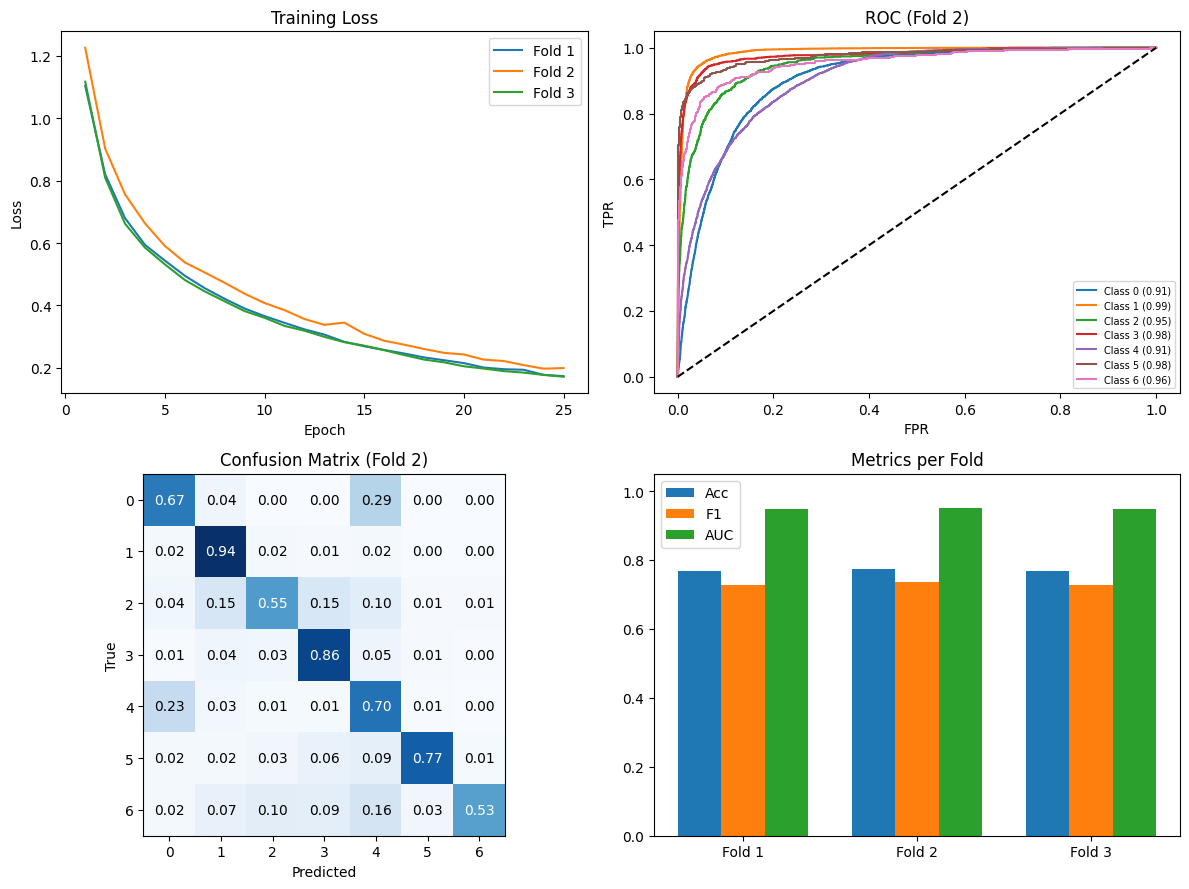

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_accuracies, fold_f1s, fold_aucs = [], [], []
fold_loss_curves, fold_preds, fold_labels, fold_probs = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_data)):
    print(f"Fold {fold+1}/3")

    train_loader = DataLoader(TextDataset(all_data.iloc[train_idx].reset_index(drop=True)), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TextDataset(all_data.iloc[val_idx].reset_index(drop=True)), batch_size=64)

    model     = LSTMClassifier(len(word_int_mapping), embed_dim, hidden_dim, num_statuses).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_loader))
        print(f"  Epoch {epoch+1}/{num_epochs} | loss: {losses[-1]:.4f}")
    fold_loss_curves.append(losses)

    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds.extend(torch.max(logits, 1)[1].cpu().tolist())
            labels.extend(y.cpu().tolist())
            probs.extend(torch.softmax(logits, dim=1).cpu().tolist())

    fold_preds.append(preds); fold_labels.append(labels); fold_probs.append(probs)
    fold_accuracies.append(sum(p==l for p,l in zip(preds,labels)) / len(labels))
    fold_f1s.append(f1_score(labels, preds, average='macro'))

    lb = label_binarize(labels, classes=list(range(num_statuses)))
    pa = np.array(probs)
    fold_aucs.append(np.mean([auc(*roc_curve(lb[:,c], pa[:,c])[:2]) for c in range(num_statuses) if lb[:,c].sum()]))

    print(f"  Acc: {fold_accuracies[-1]:.3f} | F1: {fold_f1s[-1]:.3f} | AUC: {fold_aucs[-1]:.3f}")
    print(classification_report(labels, preds))

# plots
best = int(np.argmax(fold_aucs))
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].set(title='Training Loss', xlabel='Epoch', ylabel='Loss')
for i, l in enumerate(fold_loss_curves):
    axes[0,0].plot(range(1, num_epochs+1), l, label=f'Fold {i+1}')
axes[0,0].legend()

lb = label_binarize(fold_labels[best], classes=list(range(num_statuses)))
pa = np.array(fold_probs[best])
axes[0,1].set(title=f'ROC (Fold {best+1})', xlabel='FPR', ylabel='TPR')
for c in range(num_statuses):
    if not lb[:,c].sum(): continue
    fpr, tpr, _ = roc_curve(lb[:,c], pa[:,c])
    axes[0,1].plot(fpr, tpr, label=f'Class {c} ({auc(fpr,tpr):.2f})')
axes[0,1].plot([0,1],[0,1],'k--')
axes[0,1].legend(fontsize=7)

cm = confusion_matrix(fold_labels[best], fold_preds[best])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
axes[1,0].imshow(cm_norm, cmap='Blues')
axes[1,0].set(title=f'Confusion Matrix (Fold {best+1})', xlabel='Predicted', ylabel='True')
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        axes[1,0].text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                       color='white' if cm_norm[i,j] > 0.5 else 'black')

x = np.arange(3)
for i, (label, vals) in enumerate(zip(['Acc','F1','AUC'], [fold_accuracies, fold_f1s, fold_aucs])):
    axes[1,1].bar(x + i*0.25, vals, 0.25, label=label)
axes[1,1].set(title='Metrics per Fold', ylim=(0,1.05))
axes[1,1].set_xticks(x+0.25); axes[1,1].set_xticklabels([f'Fold {i+1}' for i in range(3)])
axes[1,1].legend()

plt.tight_layout()
plt.savefig('cv_report.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report

kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_accuracies = []
fold_f1s = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_data)):
  print(f"Fold {fold+1}/3")

  train_ds     = TextDataset(all_data.iloc[train_idx].reset_index(drop=True))
  val_ds       = TextDataset(all_data.iloc[val_idx].reset_index(drop=True))

  train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
  val_loader   = DataLoader(val_ds, batch_size=64)

  model     = LSTMClassifier(len(word_int_mapping), embed_dim, hidden_dim, num_statuses).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
      x = x.to(device)
      y = y.to(device)
      optimizer.zero_grad()
      loss = criterion(model(x), y)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"  Epoch {epoch+1}/{num_epochs} | loss: {avg_loss:.4f}")

  model.eval()
  all_preds  = []
  all_labels = []
  with torch.no_grad():
    for x, y in val_loader:
      x = x.to(device)
      y = y.to(device)
      scores = model(x)
      _, predicted = torch.max(scores, dim=1)
      all_preds.extend(predicted.cpu().tolist())
      all_labels.extend(y.cpu().tolist())

  acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
  f1  = f1_score(all_labels, all_preds, average='macro')
  recall = recall_score(all_labels, all_preds, average='macro')
  precision = precision_score(all_labels, all_preds, average='macro')

  fold_accuracies.append(acc)
  fold_f1s.append(f1)
  print(f"  Accuracy: {acc:.3f} | Macro F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}")
  print(classification_report(all_labels, all_preds))

Fold 1/3
  Epoch 1/25 | loss: 1.1102
  Epoch 2/25 | loss: 0.8379
  Epoch 3/25 | loss: 0.7058
  Epoch 4/25 | loss: 0.6210
  Epoch 5/25 | loss: 0.5566
  Epoch 6/25 | loss: 0.5101
  Epoch 7/25 | loss: 0.4668
  Epoch 8/25 | loss: 0.4315
  Epoch 9/25 | loss: 0.4054
  Epoch 10/25 | loss: 0.3777
  Epoch 11/25 | loss: 0.3574
  Epoch 12/25 | loss: 0.3349
  Epoch 13/25 | loss: 0.3186
  Epoch 14/25 | loss: 0.2987
  Epoch 15/25 | loss: 0.2806
  Epoch 16/25 | loss: 0.2679
  Epoch 17/25 | loss: 0.2460
  Epoch 18/25 | loss: 0.2425
  Epoch 19/25 | loss: 0.2329
  Epoch 20/25 | loss: 0.2204
  Epoch 21/25 | loss: 0.2129
  Epoch 22/25 | loss: 0.2008
  Epoch 23/25 | loss: 0.1921
  Epoch 24/25 | loss: 0.1865
  Epoch 25/25 | loss: 0.1795
  Accuracy: 0.770 | Macro F1: 0.733 | Recall: 0.719 | Precision: 0.752
              precision    recall  f1-score   support

           0       0.64      0.65      0.64      3582
           1       0.91      0.94      0.92      5362
           2       0.65      0.53      0.